<a href="https://colab.research.google.com/github/aryanp2107/PyTorch-Essentials/blob/main/PyTorch03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import math
import numpy as np


##Softmax function

In [9]:
def softmax(x):
  return np.exp(x) / np.sum(np.exp(x), axis=0)

x = np.array([2.0, 1.0, 0.1])
outputs = softmax(x)
print('softmax numpy:', outputs)

softmax numpy: [0.65900114 0.24243297 0.09856589]


In [11]:
x = torch.tensor([2.0, 1.0, 0.1])
outputs = torch.softmax(x, dim=0)
print(outputs)

tensor([0.6590, 0.2424, 0.0986])


##Cross entropy

In [13]:
def cross_entropy(actual, predicted):
  loss = -np.sum(actual * np.log(predicted))
  return loss

y = np.array([1, 0, 0])

y_pred_good = np.array([0.7, 0.2, 0.1])
Y_pred_bad = np.array([0.1, 0.3, 0.6])
l1 = cross_entropy(y, y_pred_good)
l2 = cross_entropy(y, Y_pred_bad)
print(f"Loss1 numpy: {l1:.4f}")
print(f"Loss2 numpy: {l2:.4f}")

Loss1 numpy: 0.3567
Loss2 numpy: 2.3026


In [15]:
# the nn.CrossEntropy loss applies nn.LogSoftMax + nn.NLLLoss(nog negative likelihood)
losstf = torch.nn.CrossEntropyLoss()

y_tf = torch.tensor([0])

# nsamples x nClasses = 1 x 3
y_pred_tf = torch.tensor([[2.0, 1.0, 0.1]])
y_pred_tf_bad = torch.tensor([[0.5, 2.0, 0.3]])
l1 = losstf(y_pred_tf, y_tf)
l2 = losstf(y_pred_tf_bad, y_tf)

print(f"Loss1 torch: {l1:.4f}")
print(f"Loss2 torch: {l2:.4f}")

_, predictions = torch.max(y_pred_tf, 1)
_, predictions_bad = torch.max(y_pred_tf_bad, 1)
print(f"\nPredictions torch: {predictions}")
print(f"Predictions torch: {predictions_bad}")


Loss1 torch: 0.4170
Loss2 torch: 1.8406

Predictions torch: tensor([0])
Predictions torch: tensor([1])


In [18]:
# the nn.CrossEntropy loss applies nn.LogSoftMax + nn.NLLLoss(nog negative likelihood)
losstf = torch.nn.CrossEntropyLoss()

# 3 samples
y_tf = torch.tensor([2, 0, 1])

# nsamples x nClasses = 3 x 3
y_pred_tf = torch.tensor([[0.1, 1.0, 2.1], [2.0, 1.0, 0.1], [0.1, 3.0, 0.1]])
y_pred_tf_bad = torch.tensor([[2.1, 1.0, 0.1], [0.1, 1.0, 2.1], [0.1, 3.0, 0.1]])
l1 = losstf(y_pred_tf, y_tf)
l2 = losstf(y_pred_tf_bad, y_tf)

print(f"Loss1 torch: {l1:.4f}")
print(f"Loss2 torch: {l2:.4f}")

_, predictions = torch.max(y_pred_tf, 1)
_, predictions_bad = torch.max(y_pred_tf_bad, 1)
print(f"\nPredictions torch: {predictions}")
print(f"Predictions torch: {predictions_bad}")

Loss1 torch: 0.3018
Loss2 torch: 1.6242

Predictions torch: tensor([2, 0, 1])
Predictions torch: tensor([0, 2, 1])


##Binary class

In [ ]:
class NeuralNet2(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(NeuralNet2, self).__init__()
    self.linear1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.Linear2 = nn.Linear(hidden_size, 1)

    def forward(self, x):
      out = self.linear1(x)
      out = self.relu(out)
      out = self.linear2(out)

      y_pred = torch.sigmoid(out)
      return y_pred

model = NeuralNet2(input_size=28 * 28, hidden_size=5)
criterion = nn.BCELoss()

Multi-class

In [ ]:
import torch.nn as nn
class NeuralNet(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super(NeuralNet, self).__init__()
    self.linear1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.linear2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
      out = self.linear1(x)
      out = self.relu(out)
      out = self.linear2(out)
      return out

model = NeuralNet(input_size=28 * 28, hidden_size=5, num_classes=3)
criterion = nn.CrossEntropyLoss()  #this applies the softmax

##Activation Functions

Sigmoid — squashes output to (0, 1). Formula: σ(x) = 1/(1+e⁻ˣ). Great for binary classification output layers. Downside: gradients vanish for very large/small inputs, and outputs aren't zero-centered.

Tanh — squashes to (-1, 1). Zero-centered, which helps training. Still suffers from vanishing gradients at extremes. Often preferred over sigmoid in hidden layers.

ReLU (Rectified Linear Unit) — f(x) = max(0, x). The default workhorse. Computationally cheap, no vanishing gradient for positive values. Downside: "dying ReLU" problem — neurons outputting 0 for all inputs can stop learning entirely.

Leaky ReLU — f(x) = x if x > 0, else αx (small α like 0.01). Fixes dying ReLU by allowing a small gradient for negative inputs.

ELU (Exponential Linear Unit) — like ReLU for positives, but uses α(eˣ - 1) for negatives. Smoother, pushes mean activations closer to zero. Slightly more expensive to compute.

Swish — f(x) = x · σ(x). Self-gated, smooth, non-monotonic. Often outperforms ReLU in deep networks. Used in EfficientNet and other modern architectures.

GELU (Gaussian Error Linear Unit) — x · Φ(x), where Φ is the CDF of a standard normal. The activation behind Transformers (BERT, GPT). Smoothly gates inputs based on their magnitude.

Softmax — converts a vector of raw scores into probabilities that sum to 1. Used in the output layer for multi-class classification.




##Feed-forward Neural Network

In [22]:
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_size = 784  #28 x 28
hidden_size = 100
num_classes = 10
num_epochs = 10
batch_size = 100
learning_rate = 0.001

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=torchvision.transforms.ToTensor(), download=True)
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=torchvision.transforms.ToTensor())

In [23]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=False)

In [26]:
examples = iter(train_loader)
samples, labels = next(examples)
print(samples.shape, labels.shape)

torch.Size([100, 1, 28, 28]) torch.Size([100])


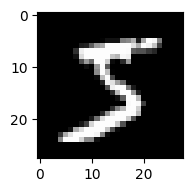

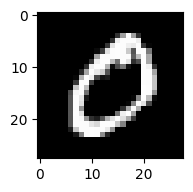

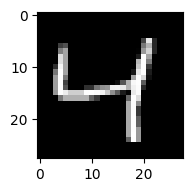

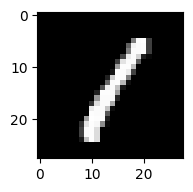

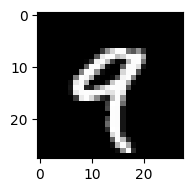

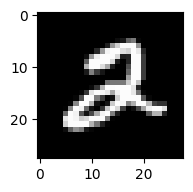

In [36]:
for i in range(6):
  plt.subplot(2, 3, i+1),
  plt.imshow(samples[i][0], cmap='gray'),
  plt.show()

In [40]:
import torch.nn as nn
class NeuralNet3(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super(NeuralNet3, self).__init__()
    self.linear1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.linear2 = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    out = self.linear1(x)
    out = self.relu(out)
    out = self.linear2(out)
    return out

model = NeuralNet3(input_size, hidden_size, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=torchvision.transforms.ToTensor())
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

#training loop
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    images = images.reshape(-1, 28*28).to(device)
    labels = labels.to(device)

    #forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)
    #backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (i+1) % 100 == 0:
      print(f'epoch {epoch+1} / {num_epochs}, step{i+1}/{n_total_steps}, loss={loss.item():.4f}')

with torch.no_grad():
  n_correct = 0
  n_samples = 0
  for images, labels in test_loader:
    images = images.reshape(-1, 28*28).to(device)
    labels = labels.to(device)
    outputs = model(images)

    _, predictions = torch.max(outputs, 1)
    n_samples += labels.shape[0]
    n_correct += (predictions == labels).sum().item()

  acc = 100.0 * n_correct / n_samples
  print(f'accuracy = {acc}')

epoch 1 / 10, step100/600, loss=0.2989
epoch 1 / 10, step200/600, loss=0.3879
epoch 1 / 10, step300/600, loss=0.4751
epoch 1 / 10, step400/600, loss=0.3664
epoch 1 / 10, step500/600, loss=0.3218
epoch 1 / 10, step600/600, loss=0.2702
epoch 2 / 10, step100/600, loss=0.1526
epoch 2 / 10, step200/600, loss=0.1784
epoch 2 / 10, step300/600, loss=0.3234
epoch 2 / 10, step400/600, loss=0.2472
epoch 2 / 10, step500/600, loss=0.2077
epoch 2 / 10, step600/600, loss=0.2308
epoch 3 / 10, step100/600, loss=0.1130
epoch 3 / 10, step200/600, loss=0.1216
epoch 3 / 10, step300/600, loss=0.2263
epoch 3 / 10, step400/600, loss=0.1730
epoch 3 / 10, step500/600, loss=0.1546
epoch 3 / 10, step600/600, loss=0.2140
epoch 4 / 10, step100/600, loss=0.0871
epoch 4 / 10, step200/600, loss=0.0983
epoch 4 / 10, step300/600, loss=0.1693
epoch 4 / 10, step400/600, loss=0.1265
epoch 4 / 10, step500/600, loss=0.1224
epoch 4 / 10, step600/600, loss=0.1985
epoch 5 / 10, step100/600, loss=0.0736
epoch 5 / 10, step200/600